INSTALLING TENSORFLOW

In [1]:
!pip install tensorflow


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np 
import tensorflow as tf

In [3]:
df1 = pd.read_csv('data-with-concern.csv')  # importing the dataset for the tire breakdown reasons
df1

,description,material_name,tonnage_percentage,speed,road_category,gradient
0,ARO/RIN/BIRLOS,INPIT,98.4,18.0,Lift,0
1,ARO/RIN/BIRLOS,INPIT,98.4,21.6,Lift,2
2,ARO/RIN/BIRLOS,INPIT,98.4,21.6,Lift,7
3,ARO/RIN/BIRLOS,INPIT,98.4,25.2,Lift,0
4,ARO/RIN/BIRLOS,INPIT,98.4,25.2,Lift,2
...,...,...,...,...,...,...
29142,ROTACION DE LLANTAS,TEPETATE,NaN,39.6,Surface,12
29143,ROTACION DE LLANTAS,TEPETATE,NaN,43.2,Lift,8
29144,ROTACION DE LLANTAS,TEPETATE,NaN,43.2,Surface,-1
29145,ROTACION DE LLANTAS,TEPETATE,NaN,43.2,Surface,12


In [8]:
df1 = df1[['description','tonnage_percentage','speed','road_category','gradient']]  # Extracting the neccessary columns
df1

,description,tonnage_percentage,speed,road_category,gradient
0,ARO/RIN/BIRLOS,98.4,18.0,Lift,0
1,ARO/RIN/BIRLOS,98.4,21.6,Lift,2
2,ARO/RIN/BIRLOS,98.4,21.6,Lift,7
3,ARO/RIN/BIRLOS,98.4,25.2,Lift,0
4,ARO/RIN/BIRLOS,98.4,25.2,Lift,2
...,...,...,...,...,...
29142,ROTACION DE LLANTAS,NaN,39.6,Surface,12
29143,ROTACION DE LLANTAS,NaN,43.2,Lift,8
29144,ROTACION DE LLANTAS,NaN,43.2,Surface,-1
29145,ROTACION DE LLANTAS,NaN,43.2,Surface,12


In [9]:
df2 = pd.read_csv('data-without-concern.csv')  # Importing the dataset for no tire breakdown reasons
df2

,description,material_name,tonnage_percentage,speed,road_category,gradient
0,A/C,INPIT,100.00,3.6,Dump,-4
1,A/C,INPIT,100.00,18.0,Dump,-4
2,A/C,LIXIVIABLE,94.89,10.8,Lift,5
3,A/C,LIXIVIABLE,94.89,14.4,Lift,4
4,A/C,LIXIVIABLE,94.89,14.4,Lift,5
...,...,...,...,...,...,...
29681,TRANSMISION,TEPETATE,NaN,25.2,Lift,5
29682,TRANSMISION,TEPETATE,NaN,28.8,Lift,-6
29683,TRANSMISION,TEPETATE,NaN,32.4,Lift,-6
29684,TRANSMISION,TEPETATE,NaN,36.0,Lift,-6


In [10]:
df2 = df2[['description','tonnage_percentage','speed','road_category','gradient']]  # Extracting the neccessary columns
df2

,description,tonnage_percentage,speed,road_category,gradient
0,A/C,100.00,3.6,Dump,-4
1,A/C,100.00,18.0,Dump,-4
2,A/C,94.89,10.8,Lift,5
3,A/C,94.89,14.4,Lift,4
4,A/C,94.89,14.4,Lift,5
...,...,...,...,...,...
29681,TRANSMISION,NaN,25.2,Lift,5
29682,TRANSMISION,NaN,28.8,Lift,-6
29683,TRANSMISION,NaN,32.4,Lift,-6
29684,TRANSMISION,NaN,36.0,Lift,-6


In [11]:
df1['description'] = 'Yes'  # Replacing the tire breakdown reasons description by a single boolean variable (which will be encoded later on while training our model)
df1

,description,tonnage_percentage,speed,road_category,gradient
0,Yes,98.4,18.0,Lift,0
1,Yes,98.4,21.6,Lift,2
2,Yes,98.4,21.6,Lift,7
3,Yes,98.4,25.2,Lift,0
4,Yes,98.4,25.2,Lift,2
...,...,...,...,...,...
29142,Yes,NaN,39.6,Surface,12
29143,Yes,NaN,43.2,Lift,8
29144,Yes,NaN,43.2,Surface,-1
29145,Yes,NaN,43.2,Surface,12


In [12]:
df2['description'] = 'No'  # Replacing the non tire breakdown reasons description by a single boolean variable (which will be encoded later on while training our model)
df2

,description,tonnage_percentage,speed,road_category,gradient
0,No,100.00,3.6,Dump,-4
1,No,100.00,18.0,Dump,-4
2,No,94.89,10.8,Lift,5
3,No,94.89,14.4,Lift,4
4,No,94.89,14.4,Lift,5
...,...,...,...,...,...
29681,No,NaN,25.2,Lift,5
29682,No,NaN,28.8,Lift,-6
29683,No,NaN,32.4,Lift,-6
29684,No,NaN,36.0,Lift,-6


In [13]:
df = pd.concat([df1, df2], ignore_index=True)  # Concating all the tire breakdown and non tire breakdown reasons to prepare final dataset
df

,description,tonnage_percentage,speed,road_category,gradient
0,Yes,98.4,18.0,Lift,0
1,Yes,98.4,21.6,Lift,2
2,Yes,98.4,21.6,Lift,7
3,Yes,98.4,25.2,Lift,0
4,Yes,98.4,25.2,Lift,2
...,...,...,...,...,...
58828,No,NaN,25.2,Lift,5
58829,No,NaN,28.8,Lift,-6
58830,No,NaN,32.4,Lift,-6
58831,No,NaN,36.0,Lift,-6


In [14]:
df = df[(df['road_category'] == 'Lift')]  # Filtering our dataset on Surface tye road categories

FINAL DATASET

In [15]:
df

,description,tonnage_percentage,speed,road_category,gradient
0,Yes,98.4,18.0,Lift,0
1,Yes,98.4,21.6,Lift,2
2,Yes,98.4,21.6,Lift,7
3,Yes,98.4,25.2,Lift,0
4,Yes,98.4,25.2,Lift,2
...,...,...,...,...,...
58828,No,NaN,25.2,Lift,5
58829,No,NaN,28.8,Lift,-6
58830,No,NaN,32.4,Lift,-6
58831,No,NaN,36.0,Lift,-6


In [16]:
df = df.fillna(0)  # Replacing all Null values by 0
df

,description,tonnage_percentage,speed,road_category,gradient
0,Yes,98.4,18.0,Lift,0
1,Yes,98.4,21.6,Lift,2
2,Yes,98.4,21.6,Lift,7
3,Yes,98.4,25.2,Lift,0
4,Yes,98.4,25.2,Lift,2
...,...,...,...,...,...
58828,No,0.0,25.2,Lift,5
58829,No,0.0,28.8,Lift,-6
58830,No,0.0,32.4,Lift,-6
58831,No,0.0,36.0,Lift,-6


DIVIDING THE FEATURE AND TARGET DATA

In [17]:
feature = df.drop(['description','road_category'], axis=1)  # Dividing feature and target columns
feature

,tonnage_percentage,speed,gradient
0,98.4,18.0,0
1,98.4,21.6,2
2,98.4,21.6,7
3,98.4,25.2,0
4,98.4,25.2,2
...,...,...,...
58828,0.0,25.2,5
58829,0.0,28.8,-6
58830,0.0,32.4,-6
58831,0.0,36.0,-6


In [18]:
X = feature.values  # Converting our features into a numpy array
X

array([[98.4, 18. ,  0. ],
       [98.4, 21.6,  2. ],
       [98.4, 21.6,  7. ],
       ...,
       [ 0. , 32.4, -6. ],
       [ 0. , 36. , -6. ],
       [ 0. , 46.8, -6. ]], shape=(16837, 3))

SCALING THE FEATURE VALUES

In [19]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import sklearn

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler = StandardScaler()

In [23]:
X = scaler.fit_transform(X)  # Scaling our feature values
X

array([[ 0.24659252, -0.58894159,  0.17596989],
       [ 0.24659252, -0.26154008,  0.45671134],
       [ 0.24659252, -0.26154008,  1.15856498],
       ...,
       [-3.43938863,  0.72066445, -0.66625448],
       [-3.43938863,  1.04806596, -0.66625448],
       [-3.43938863,  2.03027049, -0.66625448]], shape=(16837, 3))

In [24]:
df

,description,tonnage_percentage,speed,road_category,gradient
0,Yes,98.4,18.0,Lift,0
1,Yes,98.4,21.6,Lift,2
2,Yes,98.4,21.6,Lift,7
3,Yes,98.4,25.2,Lift,0
4,Yes,98.4,25.2,Lift,2
...,...,...,...,...,...
58828,No,0.0,25.2,Lift,5
58829,No,0.0,28.8,Lift,-6
58830,No,0.0,32.4,Lift,-6
58831,No,0.0,36.0,Lift,-6


ENCODING OUR FEATURE VALUES INTO YES/NO

In [26]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [27]:
label_encoder = LabelEncoder()

In [28]:
Y = label_encoder.fit_transform(df['description'])  # Encoding our boolean variable: YES-1, NO-0
Y

array([1, 1, 1, ..., 0, 0, 0], shape=(16837,))

SPLITTING OUR MODEL FOR TRAINING AND TESTING

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)  # Splitting our dataset into 80% testing and 20% testing datasets

BUILDING OUR ANN MODEL FOR RISK PREDICTION

In [32]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [33]:
model = tf.keras.models.Sequential()  # Creating a sequential neural network model

In [34]:
model.add(tf.keras.Input(shape = (3,)))   # input layer

In [35]:
model.add(tf.keras.layers.Dense(units = 32, activation = 'relu'))  # 1st hidden layer
model.add(Dropout(0.1))

In [36]:
model.add(tf.keras.layers.Dense(units = 12, activation = 'relu'))  # 2nd hidden layer

In [37]:
model.add(tf.keras.layers.Dense(units = 1, activation = 'sigmoid'))  # output layer

In [38]:
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics=['accuracy'])  # Compiling our model

In [39]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,   # stop if no improvement for 5 epochs
    restore_best_weights=True
)

In [40]:
history = model.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, Y_test),
    callbacks=[early_stop]
)

Epoch 1/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8468 - loss: 0.4057 - val_accuracy: 0.8673 - val_loss: 0.3444
Epoch 2/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8672 - loss: 0.3524 - val_accuracy: 0.8673 - val_loss: 0.3374
Epoch 3/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8686 - loss: 0.3477 - val_accuracy: 0.8729 - val_loss: 0.3341
Epoch 4/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8712 - loss: 0.3448 - val_accuracy: 0.8688 - val_loss: 0.3311
Epoch 5/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8724 - loss: 0.3425 - val_accuracy: 0.8670 - val_loss: 0.3294
Epoch 6/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8722 - loss: 0.3405 - val_accuracy: 0.8762 - val_loss: 0.3274
Epoch 7/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8741 - loss: 0.3392 - val_accuracy: 0.8747 - val_loss: 0.3253
Epoch 8/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8737 - loss: 0.3368 - val_accu

In [41]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


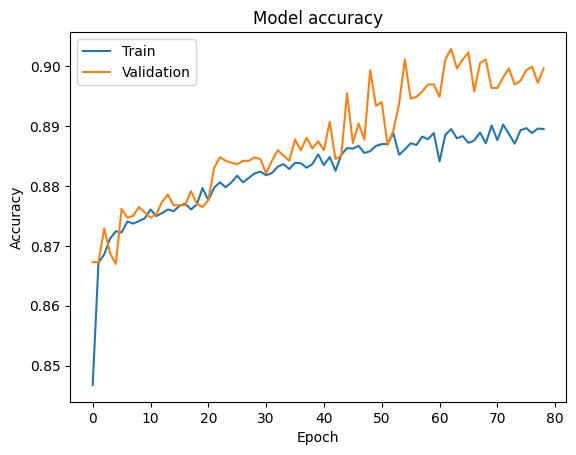

In [42]:
# Plotting the model accuracy 
import seaborn as sns
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show(block=True)

In [43]:
loss, accuracy = model.evaluate(X_test, Y_test)
print(f"\nModel Accuracy: {accuracy:.4f}")

106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8970 - loss: 0.2470

Model Accuracy: 0.8970


In [44]:
X_train

array([[ 0.287423  ,  1.37546747,  1.86041862],
       [ 0.52491407,  1.37546747,  1.29893571],
       [ 0.63279644,  1.04806596,  1.29893571],
       ...,
       [ 0.59870861, -1.24374461,  0.59708207],
       [ 0.15444299,  1.37546747, -0.94699594],
       [ 0.03344991, -0.58894159, -1.08736667]], shape=(13469, 3))

In [45]:
X_test

array([[ 0.27655985,  0.06586143, -0.10477157],
       [ 0.61481605, -0.9163431 , -1.64884958],
       [ 0.37620121, -1.57114612,  1.86041862],
       ...,
       [-0.03397657, -0.9163431 ,  0.59708207],
       [-3.43938863, -0.58894159, -0.38551303],
       [-0.04896023,  0.06586143,  1.15856498]], shape=(3368, 3))

In [46]:
Y_train

array([0, 1, 1, ..., 0, 0, 0], shape=(13469,))

In [47]:
Y_test

array([0, 0, 0, ..., 0, 0, 1], shape=(3368,))

In [48]:
Y_pred = model.predict(X_test)  # predicting the truck breakdown using our ANN model
Y_pred

106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[3.8152222e-02],
       [3.0213163e-05],
       [2.1742401e-09],
       ...,
       [8.7797381e-02],
       [1.2122527e-01],
       [6.4253163e-01]], shape=(3368, 1), dtype=float32)

In [49]:
Y_pred_binary = (Y_pred > 0.5).astype(int)
Y_pred_binary

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [1]], shape=(3368, 1))

In [50]:
len(Y_pred_binary)

3368

In [52]:
indexes_of_0s = np.where(Y_pred_binary == 0)[0]
indexes_of_1s = np.where(Y_pred_binary == 1)[0]

In [53]:
indexes_of_0s

array([   0,    1,    2, ..., 3364, 3365, 3366], shape=(3084,))

In [54]:
indexes_of_1s

array([   4,    7,    9,   10,   13,   15,   20,   40,   49,   54,   73,
         79,   83,   88,   90,  101,  128,  160,  162,  171,  183,  188,
        195,  233,  235,  238,  275,  280,  293,  295,  303,  321,  337,
        346,  353,  354,  355,  375,  378,  380,  383,  405,  408,  417,
        421,  423,  424,  431,  439,  473,  487,  501,  506,  508,  509,
        513,  558,  575,  611,  612,  615,  639,  673,  679,  730,  733,
        748,  757,  762,  771,  780,  792,  801,  822,  826,  830,  842,
        851,  903,  904,  954, 1011, 1017, 1059, 1062, 1074, 1079, 1088,
       1097, 1123, 1136, 1153, 1172, 1190, 1196, 1222, 1228, 1230, 1250,
       1286, 1303, 1318, 1329, 1335, 1347, 1361, 1371, 1380, 1389, 1418,
       1439, 1442, 1487, 1498, 1501, 1532, 1549, 1555, 1559, 1565, 1578,
       1599, 1607, 1615, 1616, 1619, 1625, 1644, 1645, 1647, 1658, 1659,
       1667, 1703, 1714, 1718, 1719, 1725, 1739, 1765, 1772, 1793, 1825,
       1868, 1872, 1899, 1905, 1914, 1918, 1920, 19

In [55]:
Y_pred_binary[2637]

array([0])

In [56]:
df_Y_pred = pd.DataFrame(Y_pred_binary, columns=['description'])
df_Y_pred

,description
0,0
1,0
2,0
3,0
4,1
...,...
3363,0
3364,0
3365,0
3366,0


In [57]:
X_test_original = scaler.inverse_transform(X_test)  # Decoding the test features into its original values
X_test_original

array([[ 99.2 ,  25.2 ,  -2.  ],
       [108.23,  14.4 , -13.  ],
       [101.86,   7.2 ,  12.  ],
       ...,
       [ 90.91,  14.4 ,   3.  ],
       [  0.  ,  18.  ,  -4.  ],
       [ 90.51,  25.2 ,   7.  ]], shape=(3368, 3))

In [58]:
df_feature_original = pd.DataFrame(X_test_original, columns=['tonnage_percentage', 'speed', 'gradient'])
df_feature_original

,tonnage_percentage,speed,gradient
0,99.20,25.2,-2.0
1,108.23,14.4,-13.0
2,101.86,7.2,12.0
3,103.80,21.6,-2.0
4,99.51,28.8,7.0
...,...,...,...
3363,100.00,10.8,5.0
3364,100.69,32.4,-2.0
3365,90.91,14.4,3.0
3366,0.00,18.0,-4.0


In [59]:
df_test = pd.concat([df_feature_original, df_Y_pred], axis=1)
df_test

,tonnage_percentage,speed,gradient,description
0,99.20,25.2,-2.0,0
1,108.23,14.4,-13.0,0
2,101.86,7.2,12.0,0
3,103.80,21.6,-2.0,0
4,99.51,28.8,7.0,1
...,...,...,...,...
3363,100.00,10.8,5.0,0
3364,100.69,32.4,-2.0,0
3365,90.91,14.4,3.0,0
3366,0.00,18.0,-4.0,0


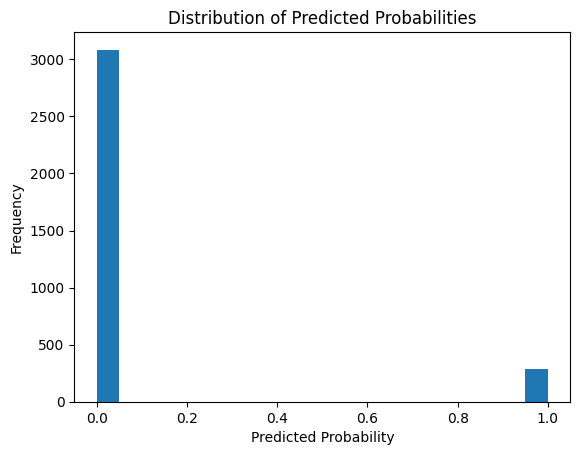

In [60]:
plt.hist(df_test['description'], bins=20)
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Distribution of Predicted Probabilities')
plt.show(block=True)

In [61]:
mapping_dict = {0: 'Cannot cause tire breakdown', 1: 'Could cause tire breakdown'}

In [62]:
df_test['description'] = df_test['description'].map(mapping_dict)  # Classifying our description values into meanigful mappings
df_test

,tonnage_percentage,speed,gradient,description
0,99.20,25.2,-2.0,Cannot cause tire breakdown
1,108.23,14.4,-13.0,Cannot cause tire breakdown
2,101.86,7.2,12.0,Cannot cause tire breakdown
3,103.80,21.6,-2.0,Cannot cause tire breakdown
4,99.51,28.8,7.0,Could cause tire breakdown
...,...,...,...,...
3363,100.00,10.8,5.0,Cannot cause tire breakdown
3364,100.69,32.4,-2.0,Cannot cause tire breakdown
3365,90.91,14.4,3.0,Cannot cause tire breakdown
3366,0.00,18.0,-4.0,Cannot cause tire breakdown


MODEL PERFORMANCE METRICS

In [63]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

In [64]:
Y_pred_binary

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [1]], shape=(3368, 1))

In [65]:
Y_test

array([0, 0, 0, ..., 0, 0, 1], shape=(3368,))

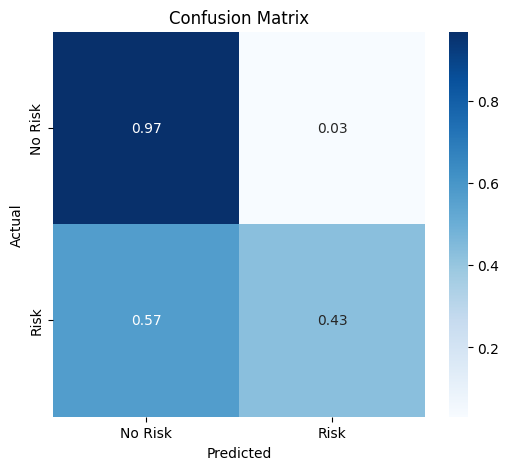

In [66]:
# CONFUSION MATRIX
import numpy as np

cm = confusion_matrix(Y_test, Y_pred_binary)

cm_percent = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,5))
sns.heatmap(cm_percent, 
            annot=True, 
            fmt=".2f", 
            cmap='Blues',
            xticklabels=["No Risk", "Risk"],
            yticklabels=["No Risk", "Risk"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [67]:
precision = precision_score(Y_test, Y_pred_binary)
recall = recall_score(Y_test, Y_pred_binary)
f1 = f1_score(Y_test, Y_pred_binary)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Precision: 0.68
Recall: 0.43
F1 Score: 0.53


In [68]:
import joblib

joblib.dump(model, "lift_model.pkl")
joblib.dump(scaler, "scaler_lift.pkl")

['scaler_lift.pkl']